<a href="https://www.kaggle.com/code/abubakarjavaid/heart-disease-indicators-phase-2-eda-preproces?scriptVersionId=303546233" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/datasets/alexteboul/heart-disease-health-indicators-dataset/heart_disease_health_indicators_BRFSS2015.csv")
df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


# Dataset Preview

*We first load the dataset and display the first few rows to understand the structure of the dataset and the available features.*

In [3]:
df.shape

(253680, 22)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

# Dataset Structure


*The dataset contains multiple health indicators such as BMI, smoking status, physical activity, and blood pressure.These variables represent clinical, behavioral, and demographic factors that may influence heart disease risk*
.

In [5]:
df.describe()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.094186,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.296921,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.292087,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.698160,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,2.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


# cecking missing value

*no missing values are present in the data set*

In [6]:
df.isnull().sum()


HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [7]:
df['HeartDiseaseorAttack'].value_counts()

HeartDiseaseorAttack
0.0    229787
1.0     23893
Name: count, dtype: int64

# VISUALIZATION

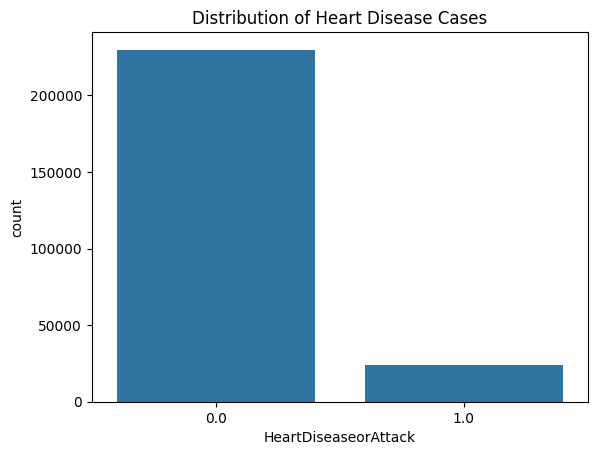

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='HeartDiseaseorAttack', data=df)
plt.title("Distribution of Heart Disease Cases")
plt.show()

*This plot shows the distribution of the target variable HeartDiseaseorAttack. Most individuals in the dataset do not have heart disease, indicating a class imbalance where the negative class dominates the dataset.*

# BMI Distribution

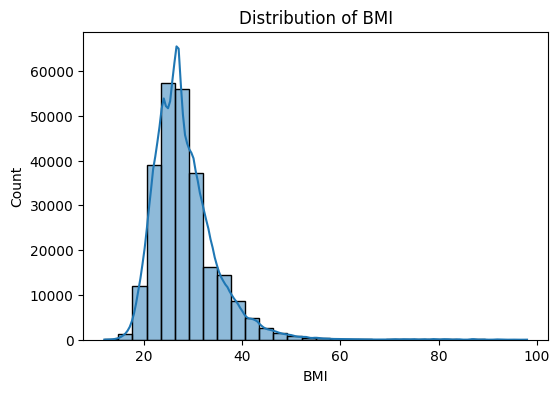

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['BMI'], bins=30, kde=True)
plt.title("Distribution of BMI")
plt.show()

*This histogram shows the distribution of BMI values in the dataset. Most individuals fall within moderate BMI ranges, while extremely high BMI values occur less frequently. This suggests the majority of individuals are in normal or overweight categories.*

# HighBP vs Heart Disease

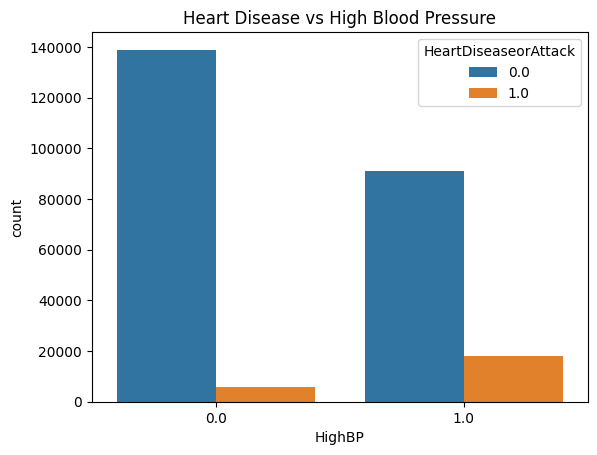

In [10]:
sns.countplot(x='HighBP', hue='HeartDiseaseorAttack', data=df)
plt.title("Heart Disease vs High Blood Pressure")
plt.show()

*This plot compares heart disease occurrence between individuals with and without high blood pressure. The results suggest that individuals with high blood pressure tend to show a higher proportion of heart disease cases, indicating that HighBP may be an important risk factor.*

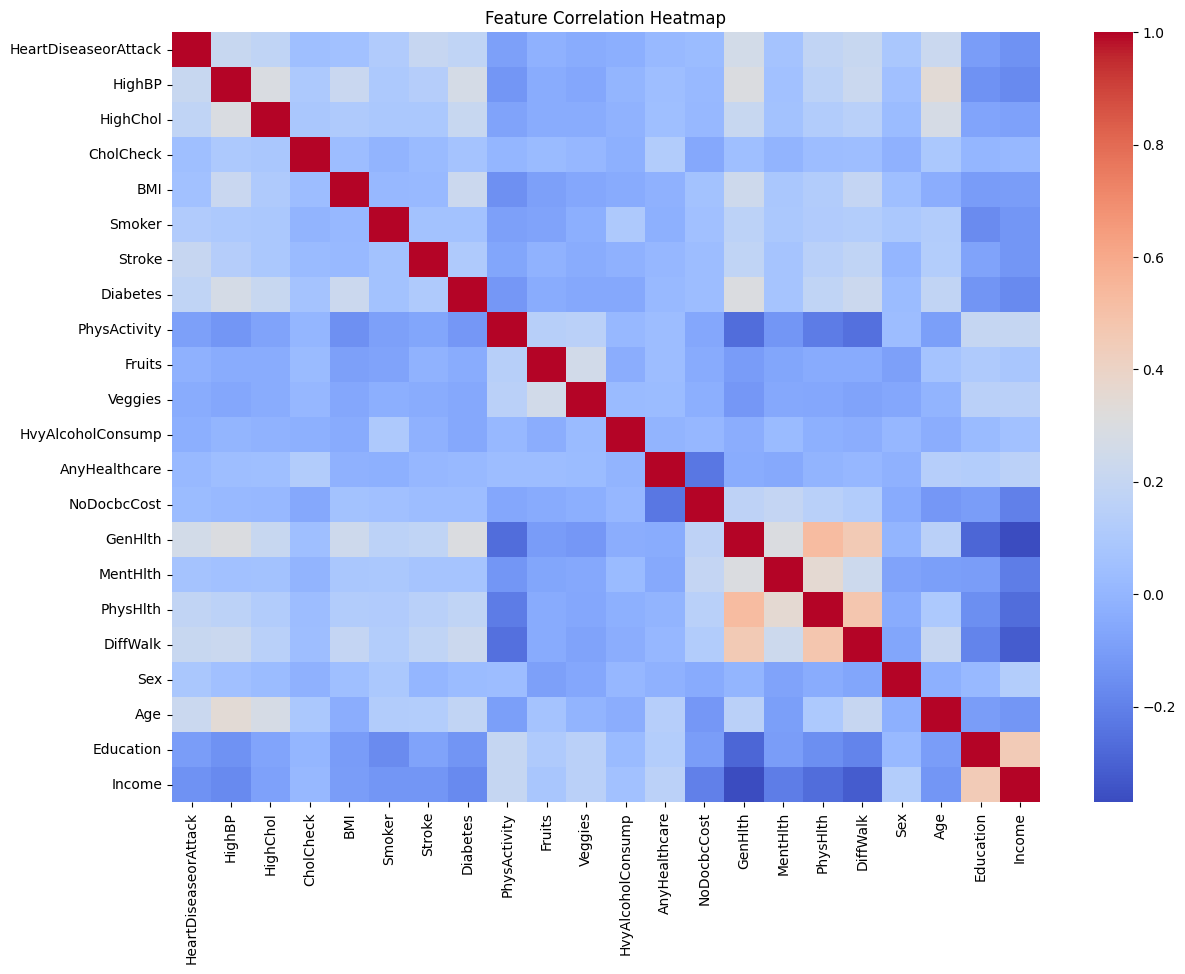

In [11]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

*The correlation heatmap visualizes the relationships between different health indicators in the dataset. Variables with stronger correlation values indicate a stronger relationship. This analysis helps identify features that may significantly influence heart disease risk.*

# Smoking + HighBP

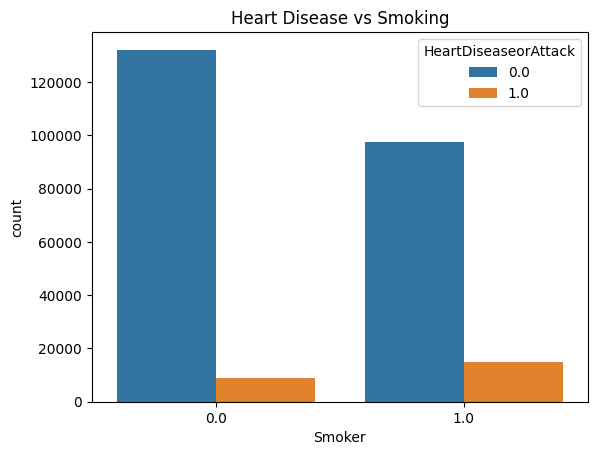

In [12]:
sns.countplot(x='Smoker', hue='HeartDiseaseorAttack', data=df)
plt.title("Heart Disease vs Smoking")
plt.show()

*This plot shows the relationship between smoking behavior and heart disease occurrence. Individuals who smoke tend to show a higher proportion of heart disease cases compared to non-smokers, suggesting smoking may increase cardiovascular risk.*

In [13]:
df = df.astype(int)

# Check Duplicates

In [14]:
df.duplicated().sum()

np.int64(23899)

# Remove Duplicates
*as found more than 200 *

In [15]:
df = df.drop_duplicates()

# Feature Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['BMI','MentHlth','PhysHlth']] = scaler.fit_transform(df[['BMI','MentHlth','PhysHlth']])

In [17]:
df.to_csv("heart_disease_preprocessed.csv", index=False)